# FOXF1_bead — 02_manual_bead_well_annotation

**Feeds:** Fig 2c, ED Fig 3d

**Position in the chain:** run the numbered notebooks in order

Ported unchanged from the original analysis: outputs are as they ran, and no code
cell was edited. Paths appear as `<analysis-root>/...`.


# 02 | Manual Bead-Well Annotation (Large Images, 2026-01-22)

This notebook is for centroid annotation/review only.

It **does not** recompute SMALL↔LARGE alignment.
Run `notebooks/01_small_large_alignment.ipynb` first to generate
`results/annotations/small_to_large_pair_transforms.tsv`.

Annotation behavior:
- The widget shows large-image Brightfield, Alexa Fluor 647, and BF+647.
- The default displayed z-slice is bead-friendly, chosen from the large-image 647 signal.
- `Bead Z` and `Cyst Focus Z` buttons let you jump between the bead-friendly slice and the cyst-focus slice.
- Only bead x,y is saved; z is for visualization only.


In [ ]:
import os
import sys
from pathlib import Path

import pandas as pd

# Keep matplotlib cache writable inside the workspace.
MPL_TMP = (
    (Path.cwd().resolve() / "../.mplconfig").resolve()
    if (Path.cwd().resolve().name == "notebooks")
    else (Path.cwd().resolve() / ".mplconfig")
)
MPL_TMP.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_TMP))

# Resolve project root whether notebook is launched from repo root or /notebooks.
CWD = Path.cwd().resolve()
if (CWD / "scripts").exists() and (CWD / "results").exists():
    ROOT = CWD
elif (CWD.parent / "scripts").exists() and (CWD.parent / "results").exists():
    ROOT = CWD.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts import manual_well_annotation as mwa

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

print("ROOT:", ROOT)
print("Python:", sys.executable)

ROOT: <analysis-root>/FOXF1_bead
Python: /opt/anaconda3/bin/python


In [ ]:
# Parameters
TARGET_SUBDIR = "data/2026-01-22_PDMS/day2/single/"
COHORT_ID = "2026-01-22_day2_live"

LARGE_CENTROID_TSV = ROOT / "results/annotations/well_centroids_large.tsv"
PAIR_TRANSFORM_TSV = ROOT / "results/annotations/small_to_large_pair_transforms.tsv"

LIMIT = None  # set int for a quick subset
REVIEW_ONLY = False  # True = review/pass only, no editing

print("TARGET_SUBDIR:", TARGET_SUBDIR)
print("COHORT_ID:", COHORT_ID)
print("LARGE_CENTROID_TSV:", LARGE_CENTROID_TSV)
print("PAIR_TRANSFORM_TSV:", PAIR_TRANSFORM_TSV)
print("LIMIT:", LIMIT)
print("REVIEW_ONLY:", REVIEW_ONLY)

TARGET_SUBDIR: data/2026-01-22_PDMS/day2/single/
COHORT_ID: 2026-01-22_day2_live
LARGE_CENTROID_TSV: <analysis-root>/FOXF1_bead/results/annotations/well_centroids_large.tsv
PAIR_TRANSFORM_TSV: <analysis-root>/FOXF1_bead/results/annotations/small_to_large_pair_transforms.tsv
LIMIT: None
REVIEW_ONLY: False


In [ ]:
# Build strict small/large pairs from the 2026-01-22 folder.
pairs = mwa.paired_records_from_directory(
    root=ROOT,
    target_subdir=TARGET_SUBDIR,
    cohort_id=COHORT_ID,
    limit=LIMIT,
)

pairs_df = pd.DataFrame([p.__dict__ for p in pairs])
print(f"Paired records: {len(pairs)}")
if not pairs_df.empty:
    bad_small = (
        pairs_df["small_file_path"].str.contains("-large.czi", regex=False).sum()
    )
    bad_large = (~pairs_df["large_file_path"].str.endswith("-large.czi")).sum()
    print("Rows with invalid small path suffix:", int(bad_small))
    print("Rows with invalid large path suffix:", int(bad_large))
    if int(bad_small) > 0 or int(bad_large) > 0:
        raise RuntimeError("Pair validation failed: unexpected filename suffixes.")
    display(pairs_df)
else:
    print("No strict pairs found.")

Paired records: 36
Rows with invalid small path suffix: 0
Rows with invalid large path suffix: 0


                    image_id             cohort_id canonical_position                           small_file_path                                 large_file_path
0   2026-01-22_day2_live_1-1  2026-01-22_day2_live                1-1  data/2026-01-22_PDMS/day2/single/1-1.czi  data/2026-01-22_PDMS/day2/single/1-1-large.czi
1   2026-01-22_day2_live_1-2  2026-01-22_day2_live                1-2  data/2026-01-22_PDMS/day2/single/1-2.czi  data/2026-01-22_PDMS/day2/single/1-2-large.czi
2   2026-01-22_day2_live_1-3  2026-01-22_day2_live                1-3  data/2026-01-22_PDMS/day2/single/1-3.czi  data/2026-01-22_PDMS/day2/single/1-3-large.czi
3   2026-01-22_day2_live_1-4  2026-01-22_day2_live                1-4  data/2026-01-22_PDMS/day2/single/1-4.czi  data/2026-01-22_PDMS/day2/single/1-4-large.czi
4   2026-01-22_day2_live_1-5  2026-01-22_day2_live                1-5  data/2026-01-22_PDMS/day2/single/1-5.czi  data/2026-01-22_PDMS/day2/single/1-5-large.czi
5   2026-01-22_day2_live_1-6  2026-01-22

In [ ]:
# Load precomputed transforms (no recomputation in this notebook).
if not PAIR_TRANSFORM_TSV.exists():
    raise FileNotFoundError(
        "Missing transform table: "
        f"{PAIR_TRANSFORM_TSV}. "
        "Run notebooks/01_small_large_alignment.ipynb first."
    )

all_transforms = mwa.load_pair_transform_table(PAIR_TRANSFORM_TSV)
want_large = {p.large_file_path for p in pairs}
transforms_df = all_transforms[
    all_transforms["large_file_path"].isin(want_large)
].copy()
transforms_df = transforms_df.sort_values(
    ["cohort_id", "canonical_position"]
).reset_index(drop=True)

print("Loaded transform rows for subset:", len(transforms_df))
if transforms_df.empty:
    raise RuntimeError("No transform rows found for selected pairs.")

status_counts = transforms_df["registration_status"].value_counts(dropna=False)
print("Registration status counts:")
display(status_counts.to_frame("n"))

missing_pairs = sorted(want_large - set(transforms_df["large_file_path"].astype(str)))
if missing_pairs:
    print("Missing transform rows for", len(missing_pairs), "pair(s).")
    display(pd.DataFrame({"missing_large_file_path": missing_pairs}))

failed = transforms_df[transforms_df["registration_status"] != "ok"].copy()
if not failed.empty:
    print("Non-ok transform rows:", len(failed))
    display(
        failed[
            [
                "canonical_position",
                "small_file_path",
                "large_file_path",
                "registration_status",
            ]
        ]
    )

if missing_pairs or (not failed.empty):
    raise RuntimeError(
        "Transforms incomplete or non-ok. "
        "Fix/recompute in notebooks/01_small_large_alignment.ipynb before annotation."
    )

display(transforms_df)

Loaded transform rows for subset: 36
Registration status counts:


                      n
registration_status    
ok                   36

                    image_id             cohort_id canonical_position                           small_file_path                                 large_file_path registration_status  small_shape_y_px  small_shape_x_px  \
0   2026-01-22_day2_live_1-1  2026-01-22_day2_live                1-1  data/2026-01-22_PDMS/day2/single/1-1.czi  data/2026-01-22_PDMS/day2/single/1-1-large.czi                  ok              1026              1025   
1   2026-01-22_day2_live_1-2  2026-01-22_day2_live                1-2  data/2026-01-22_PDMS/day2/single/1-2.czi  data/2026-01-22_PDMS/day2/single/1-2-large.czi                  ok              1024              1024   
2   2026-01-22_day2_live_1-3  2026-01-22_day2_live                1-3  data/2026-01-22_PDMS/day2/single/1-3.czi  data/2026-01-22_PDMS/day2/single/1-3-large.czi                  ok              1024              1024   
3   2026-01-22_day2_live_1-4  2026-01-22_day2_live                1-4  data/2026-01-22_PDMS/day2/single/1-4.czi  data/2026-0

In [ ]:
# Coverage before annotation/review.
progress_before = mwa.large_centroid_progress_for_pairs(
    pairs=pairs,
    centroid_path=LARGE_CENTROID_TSV,
)
if progress_before.empty:
    print("No paired records to annotate.")
else:
    done_n = int((progress_before["annotation_status"] != "unannotated").sum())
    total_n = int(len(progress_before))
    no_bead_n = int((progress_before["annotation_status"] == "no_bead").sum())
    print(
        f"Coverage before: {done_n}/{total_n} images have saved status (annotated or no_bead)."
    )
    print(f"Explicit no_bead rows: {no_bead_n}")
    display(progress_before)

Coverage before: 0/36 images have saved status (annotated or no_bead).
Explicit no_bead rows: 0


                    image_id             cohort_id canonical_position                           small_file_path                                 large_file_path annotation_status  n_centroids  has_record
0   2026-01-22_day2_live_1-1  2026-01-22_day2_live                1-1  data/2026-01-22_PDMS/day2/single/1-1.czi  data/2026-01-22_PDMS/day2/single/1-1-large.czi       unannotated            0       False
1   2026-01-22_day2_live_1-2  2026-01-22_day2_live                1-2  data/2026-01-22_PDMS/day2/single/1-2.czi  data/2026-01-22_PDMS/day2/single/1-2-large.czi       unannotated            0       False
2   2026-01-22_day2_live_1-3  2026-01-22_day2_live                1-3  data/2026-01-22_PDMS/day2/single/1-3.czi  data/2026-01-22_PDMS/day2/single/1-3-large.czi       unannotated            0       False
3   2026-01-22_day2_live_1-4  2026-01-22_day2_live                1-4  data/2026-01-22_PDMS/day2/single/1-4.czi  data/2026-01-22_PDMS/day2/single/1-4-large.czi       unannotated           

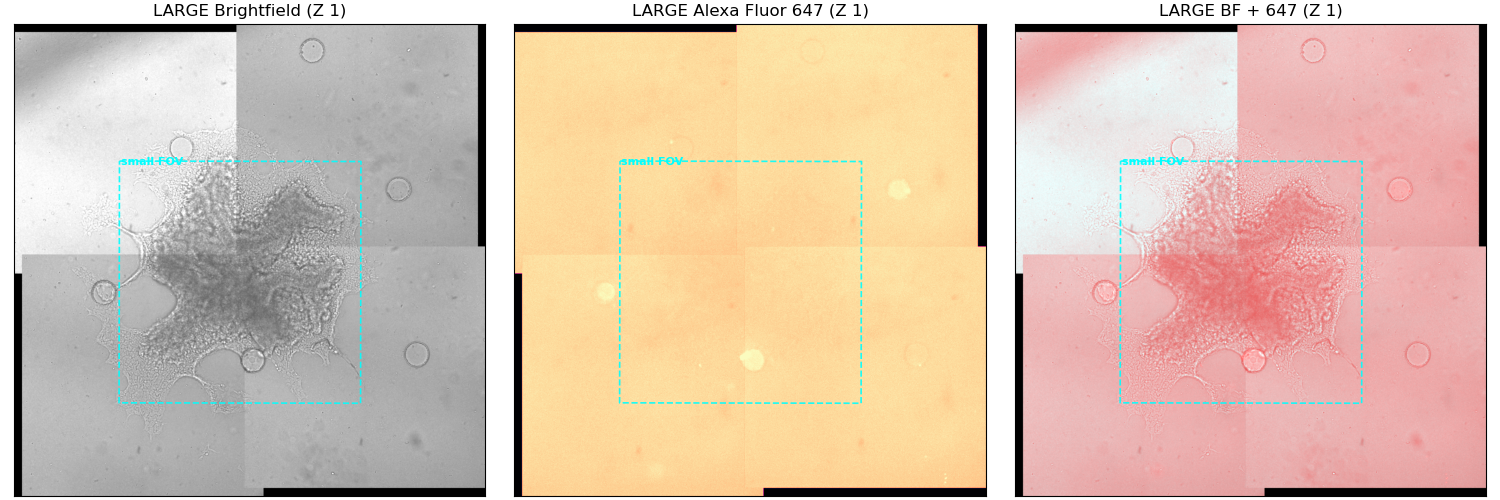

Annotation controls: Left-click to add centroid(s) on BF, 647, or BF+647. The widget defaults to a bead-friendly z from Alexa Fluor 647. Use Bead Z / Cyst Focus Z to jump between suggested planes. Save Centers + Next writes x,y only. No Bead + Next writes explicit no_bead status. Use Clear No Bead / Erase All / Undo for corrections.


In [ ]:
# Interactive centroid UI on registered LARGE images.
# Requires ipympl for widget backend.
%matplotlib widget

session = mwa.ManualLargeWellCentroidSession(
    pairs=pairs,
    root=ROOT,
    centroid_path=LARGE_CENTROID_TSV,
    transform_path=PAIR_TRANSFORM_TSV,
    allow_add=(not REVIEW_ONLY),
)
session.render()

if REVIEW_ONLY:
    print(
        "Review mode controls: Previous / Pass (no editing). Use Bead Z / Cyst Focus Z to change displayed slice."
    )
else:
    print(
        "Annotation controls: Left-click to add centroid(s) on BF, 647, or BF+647. "
        "The widget defaults to a bead-friendly z from Alexa Fluor 647. "
        "Use Bead Z / Cyst Focus Z to jump between suggested planes. "
        "Save Centers + Next writes x,y only. No Bead + Next writes explicit no_bead status. "
        "Use Clear No Bead / Erase All / Undo for corrections."
    )

In [ ]:
# Coverage after annotation/review.
progress_after = mwa.large_centroid_progress_for_pairs(
    pairs=pairs,
    centroid_path=LARGE_CENTROID_TSV,
)
if progress_after.empty:
    print("No records to report.")
else:
    done_n = int((progress_after["annotation_status"] != "unannotated").sum())
    total_n = int(len(progress_after))
    no_bead_n = int((progress_after["annotation_status"] == "no_bead").sum())
    missing = progress_after[
        progress_after["annotation_status"] == "unannotated"
    ].copy()

    print(
        f"Coverage after: {done_n}/{total_n} images have saved status (annotated or no_bead)."
    )
    print(f"Explicit no_bead rows: {no_bead_n}")
    print("Unannotated rows:", len(missing))

    display(progress_after)
    if not missing.empty:
        display(missing[["canonical_position", "small_file_path", "large_file_path"]])

Coverage after: 36/36 images have saved status (annotated or no_bead).
Explicit no_bead rows: 0
Unannotated rows: 0


                    image_id             cohort_id canonical_position                           small_file_path                                 large_file_path annotation_status  n_centroids  has_record
0   2026-01-22_day2_live_1-1  2026-01-22_day2_live                1-1  data/2026-01-22_PDMS/day2/single/1-1.czi  data/2026-01-22_PDMS/day2/single/1-1-large.czi         annotated            3        True
1   2026-01-22_day2_live_1-2  2026-01-22_day2_live                1-2  data/2026-01-22_PDMS/day2/single/1-2.czi  data/2026-01-22_PDMS/day2/single/1-2-large.czi         annotated            3        True
2   2026-01-22_day2_live_1-3  2026-01-22_day2_live                1-3  data/2026-01-22_PDMS/day2/single/1-3.czi  data/2026-01-22_PDMS/day2/single/1-3-large.czi         annotated            3        True
3   2026-01-22_day2_live_1-4  2026-01-22_day2_live                1-4  data/2026-01-22_PDMS/day2/single/1-4.czi  data/2026-01-22_PDMS/day2/single/1-4-large.czi         annotated           

In [ ]:
# Full saved centroid rows for this paired subset.
subset_centroids = mwa.large_centroid_rows_for_pairs(
    pairs=pairs,
    centroid_path=LARGE_CENTROID_TSV,
)
print("Saved large-centroid rows:", len(subset_centroids))
if not subset_centroids.empty:
    display(subset_centroids)

Saved large-centroid rows: 90


                    image_id             cohort_id canonical_position                           small_file_path                                 large_file_path annotation_status  centroid_index  centroid_x_px  \
0   2026-01-22_day2_live_1-1  2026-01-22_day2_live                1-1  data/2026-01-22_PDMS/day2/single/1-1.czi  data/2026-01-22_PDMS/day2/single/1-1-large.czi         annotated               1     382.001707   
1   2026-01-22_day2_live_1-1  2026-01-22_day2_live                1-1  data/2026-01-22_PDMS/day2/single/1-1.czi  data/2026-01-22_PDMS/day2/single/1-1-large.czi         annotated               2    1011.360805   
2   2026-01-22_day2_live_1-1  2026-01-22_day2_live                1-1  data/2026-01-22_PDMS/day2/single/1-1.czi  data/2026-01-22_PDMS/day2/single/1-1-large.czi         annotated               3    1627.962623   
3   2026-01-22_day2_live_1-2  2026-01-22_day2_live                1-2  data/2026-01-22_PDMS/day2/single/1-2.czi  data/2026-01-22_PDMS/day2/single/1-2-la